# Legacy thinking-mode EL results (bugged-run, corrected metadata)

Reads `el-evaluation/scores_legacy_thinking.csv` (9 runs: 3 models × {low,medium,high}), built by 
`build_legacy_thinking_scores.py` from the salvaged `el-results-bugged-run/` thinking-mode runs. 
Per the folder README the recorded temperature was wrong (EPG ran at 0.1, reranker/selector at 0.0); 
filenames and metadata have been corrected to `t0.1`. Metrics are recomputed from the existing 
`.spacy` predictions (no re-inference).

Figures mirror `el_metrics_notebook.ipynb`: an F1 heatmap (models × thinking modes) and an 
inference-time-vs-F1 scatter per model/think-mode, saved with a `_legacy` suffix.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

SCORES_CSV = Path('el-evaluation/scores_legacy_thinking.csv')
df = pd.read_csv(SCORES_CSV)

THINK_ORDER = ['low', 'medium', 'high']
THINK_MARKERS = {'false': 'o', 'low': '^', 'medium': 's', 'high': 'D'}
MODEL_COLORS = {
    'deepseek-v4-flash': '#0b6aae', 'deepseek-v4-pro': '#287f8c',
    'gemma4:31b': '#af200d', 'glm-5.1': '#e07b39', 'kimi-k2.7-code': '#842cbe',
    'mistral-large-3:675b': '#2e8b57', 'qwen3.5:397b': '#b8860b', 'cogito-2.1:671b': '#d81b60',
}

df['think'] = pd.Categorical(df['think'].astype(str).str.lower(),
                             categories=THINK_ORDER, ordered=True)
df['duration_min'] = df['duration_seconds'] / 60.0

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    path = FIG_DIR / f'{name}.png'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'saved {path}')

print(df[['model', 'think', 'temperature', 'duration_min', 'wd_f1', 'gn_f1', 'nil_wd_f1']])


               model   think  temperature  duration_min   wd_f1   gn_f1  \
0  deepseek-v4-flash    high          0.1    137.418333  0.7739  0.3269   
1  deepseek-v4-flash     low          0.1    154.276667  0.7337  0.3178   
2  deepseek-v4-flash  medium          0.1    146.343333  0.7638  0.3103   
3         gemma4:31b    high          0.1    199.721667  0.7582  0.4151   
4         gemma4:31b     low          0.1    340.175000  0.7624  0.3762   
5         gemma4:31b  medium          0.1    275.830000  0.7667  0.4000   
6     kimi-k2.7-code    high          0.1    260.195000  0.6233  0.3538   
7     kimi-k2.7-code     low          0.1    340.020000  0.6699  0.3387   
8     kimi-k2.7-code  medium          0.1    308.280000  0.6961  0.3840   

   nil_wd_f1  
0     0.7801  
1     0.7660  
2     0.7801  
3     0.8354  
4     0.8176  
5     0.8500  
6     0.6400  
7     0.6866  
8     0.7206  


/tmp/ipykernel_2392/4159220455.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index='model', columns='think', values=metric_col, aggfunc='first')


saved figures/Wikidata_f1_legacy.png


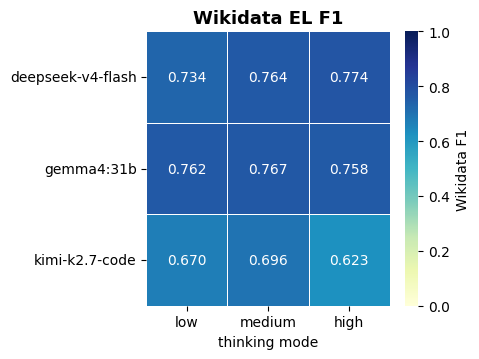

think,low,medium,high
model,,,
deepseek-v4-flash,0.7337,0.7638,0.7739
gemma4:31b,0.7624,0.7667,0.7582
kimi-k2.7-code,0.6699,0.6961,0.6233


/tmp/ipykernel_2392/4159220455.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index='model', columns='think', values=metric_col, aggfunc='first')


saved figures/GeoNames_f1_legacy.png


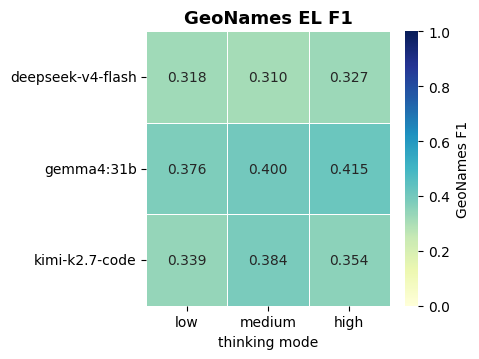

think,low,medium,high
model,,,
deepseek-v4-flash,0.3178,0.3103,0.3269
gemma4:31b,0.3762,0.4000,0.4151
kimi-k2.7-code,0.3387,0.3840,0.3538


/tmp/ipykernel_2392/4159220455.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index='model', columns='think', values=metric_col, aggfunc='first')


saved figures/NIL_Wikidata_f1_legacy.png


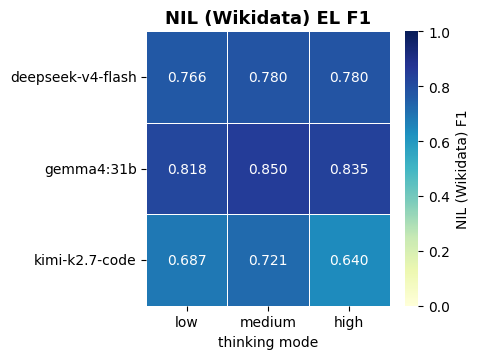

think,low,medium,high
model,,,
deepseek-v4-flash,0.7660,0.7801,0.7801
gemma4:31b,0.8176,0.8500,0.8354
kimi-k2.7-code,0.6866,0.7206,0.6400


In [18]:
def plot_f1_heatmap(metric_col, metric_label):
    """Heatmap: models (rows) x thinking modes (columns), F1 as values."""
    pivot = df.pivot_table(index='model', columns='think', values=metric_col, aggfunc='first')
    pivot = pivot.reindex(columns=THINK_ORDER)
    fig, ax = plt.subplots(figsize=(max(3, len(pivot.columns) * 1.6), len(pivot.index) * 0.9 + 1))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={'label': f'{metric_label} F1'}, ax=ax)
    ax.set_title(f'{metric_label} EL F1', fontsize=13, fontweight='bold')
    ax.set_ylabel('')
    ax.set_xlabel('thinking mode')
    plt.yticks(rotation=0)
    plt.xticks(rotation=0)
    plt.tight_layout()
    file_slug = metric_label.replace(' ', '_').replace('(', '').replace(')', '')
    save_fig(fig, f'{file_slug}_f1_legacy')
    plt.show()
    display(pivot.round(4))

for col, label in [('wd_f1', 'Wikidata'), ('gn_f1', 'GeoNames'), ('nil_wd_f1', 'NIL (Wikidata)')]:
    plot_f1_heatmap(col, label)


### Wikidata F1 vs Inference Time

> Note: This data is not extremely reliable as it includes

saved figures/f1_vs_inference_legacy.png


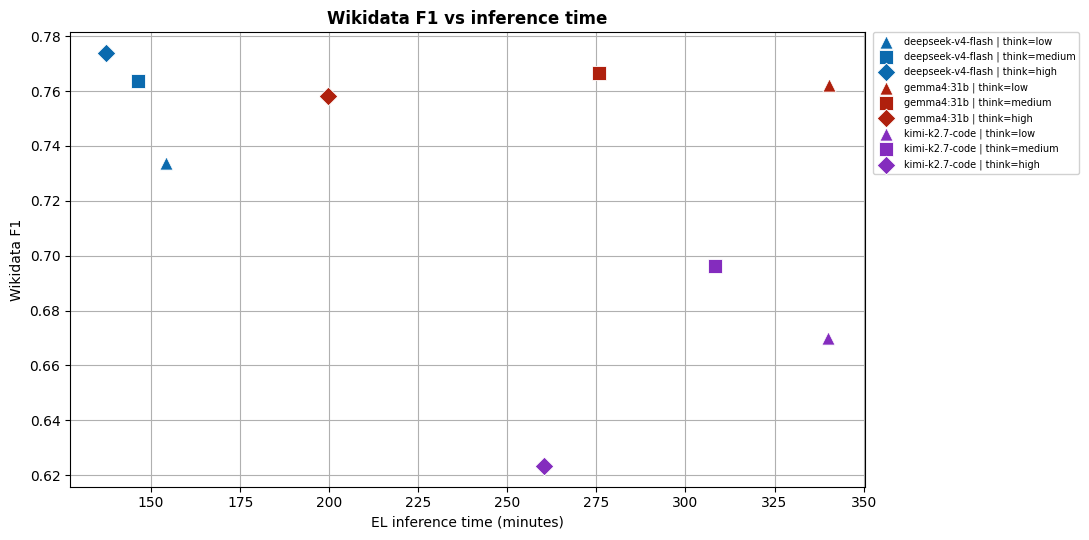

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for model in df['model'].unique():
    sub = df[df['model'] == model]
    for think in THINK_ORDER:
        s = sub[sub['think'] == think]
        if s.empty:
            continue
        ax.scatter(s['duration_min'], s['wd_f1'],
                   c=MODEL_COLORS.get(model, '#888'), marker=THINK_MARKERS[think],
                   s=90, edgecolor='white', linewidth=0.6, zorder=3,
                   label=f'{model} | think={think}')

ax.set_xlabel('EL inference time (minutes)')
ax.set_ylabel('Wikidata F1')
ax.set_title('Wikidata F1 vs inference time', fontweight='bold')
ax.legend(fontsize=7, ncol=1, loc='upper left', bbox_to_anchor=(1.01, 1),
           borderaxespad=0, framealpha=0.9, edgecolor='#ccc')
plt.tight_layout()
ax.grid()
save_fig(fig, 'f1_vs_inference_legacy')

plt.show()


### Precision vs Recall

Each run as Wikidata precision (y) vs recall (x), with iso-F1 contours. Mirrors the 
`precision_vs_recall` plot in `el_metrics_notebook.ipynb` but for the legacy thinking-mode runs. 
Shows whether a config's Wikidata F1 gains come from precision or recall.

saved figures/precision_vs_recall_legacy.png


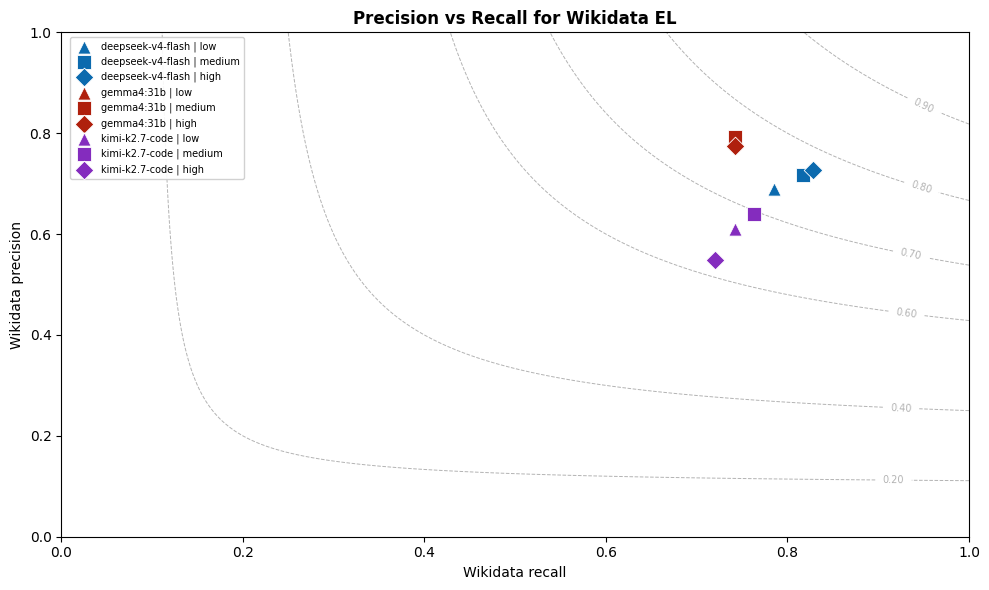

In [20]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# iso-F1 contours
p_grid, r_grid = np.meshgrid(np.linspace(0.01, 1, 120), np.linspace(0.01, 1, 120))
f1_grid = 2 * p_grid * r_grid / (p_grid + r_grid)
cs = ax.contour(r_grid, p_grid, f1_grid, levels=[0.2, 0.4, 0.6, 0.7, 0.8, 0.9],
                colors='grey', linewidths=0.7, linestyles='--', alpha=0.6)
ax.clabel(cs, inline=True, fontsize=7, fmt='%.2f')

for model in df['model'].unique():
    sub = df[df['model'] == model]
    for think in THINK_ORDER:
        s = sub[sub['think'] == think]
        if s.empty:
            continue
        ax.scatter(s['wd_r'], s['wd_p'], c=MODEL_COLORS.get(model, '#888'),
                   marker=THINK_MARKERS[think], s=90, edgecolor='white',
                   linewidth=0.6, label=f'{model} | {think}', zorder=3)

ax.set_xlabel('Wikidata recall')
ax.set_ylabel('Wikidata precision')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Precision vs Recall for Wikidata EL', fontweight='bold')

ax.legend(fontsize=7, ncol=1, loc='upper left', bbox_to_anchor=(0.01, 0.99),
          bbox_transform=ax.transAxes, borderaxespad=0, framealpha=0.9, edgecolor='#ccc')

plt.tight_layout()
save_fig(fig, 'precision_vs_recall_legacy')
plt.show()

### Precision vs Recall: NIL (Wikidata)

Same idea as the Wikidata plot above, but for **NIL abstention from a Wikidata QID**: each run as 
NIL-Wikidata precision (y) vs recall (x), with iso-F1 contours. Shows whether a config's NIL-Wikidata 
gains come from precision or recall.

saved figures/nil_wd_precision_vs_recall_legacy.png


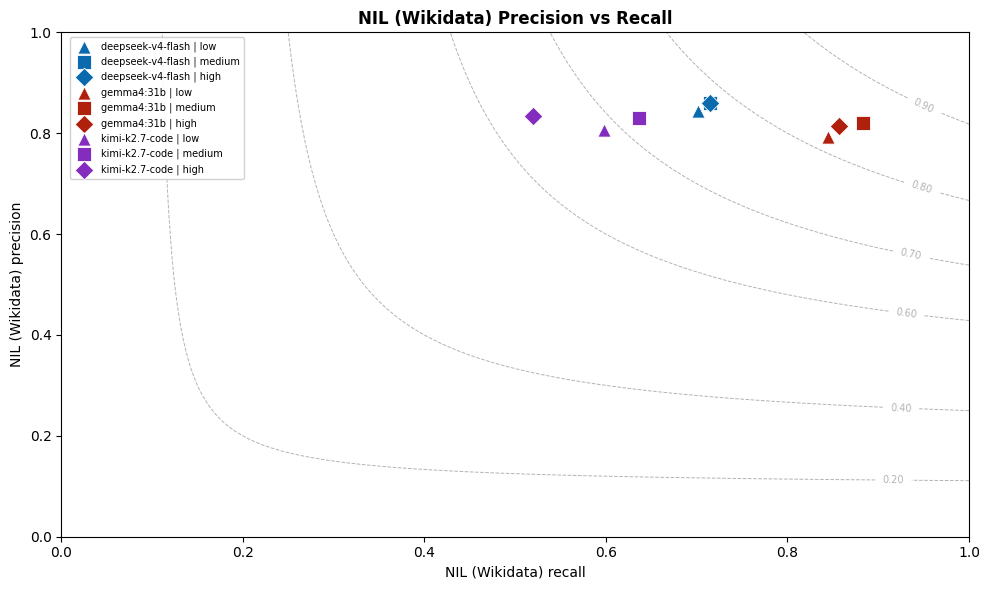

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

# iso-F1 contours (same grid as the Wikidata plot)
p_grid, r_grid = np.meshgrid(np.linspace(0.01, 1, 120), np.linspace(0.01, 1, 120))
f1_grid = 2 * p_grid * r_grid / (p_grid + r_grid)
cs = ax.contour(r_grid, p_grid, f1_grid, levels=[0.2, 0.4, 0.6, 0.7, 0.8, 0.9],
                colors='grey', linewidths=0.7, linestyles='--', alpha=0.6)
ax.clabel(cs, inline=True, fontsize=7, fmt='%.2f')

for model in df['model'].unique():
    sub = df[df['model'] == model]
    for think in THINK_ORDER:
        s = sub[sub['think'] == think]
        if s.empty:
            continue
        ax.scatter(s['nil_wd_r'], s['nil_wd_p'], c=MODEL_COLORS.get(model, '#888'),
                   marker=THINK_MARKERS[think], s=90, edgecolor='white',
                   linewidth=0.6, label=f'{model} | {think}', zorder=3)

ax.set_xlabel('NIL (Wikidata) recall')
ax.set_ylabel('NIL (Wikidata) precision')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('NIL (Wikidata) Precision vs Recall', fontweight='bold')

ax.legend(fontsize=7, ncol=1, loc='upper left', bbox_to_anchor=(0.01, 0.99),
          bbox_transform=ax.transAxes, borderaxespad=0, framealpha=0.9, edgecolor='#ccc')

plt.tight_layout()
save_fig(fig, 'nil_wd_precision_vs_recall_legacy')
plt.show()